<a href="https://colab.research.google.com/github/hsultova/Softuni-AI-Agents-Workflows/blob/main/exam/exam_multi_agent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up


*   OPENAI_API_KEY must be set as a Colab secret
*   Data file (recipes.md) should be uploaded if not found at /content/



# TODO: Project description

In [1]:
!pip install -q langchain langchain-openai langchain_text_splitters langchain_chroma

In [2]:
import json
import re
import uuid
from collections import Counter

from typing import TypedDict, Literal, Annotated, Optional, List
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from IPython.display import Image, HTML

from google.colab import userdata, files

from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain.messages import HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage, AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import create_retriever_tool
from langchain.tools import ToolRuntime, tool
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import HumanInTheLoopMiddleware

from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langgraph.types import interrupt, Command, Interrupt
from langgraph.graph.message import add_messages


In [3]:
def pretty(value) -> str:
  if isinstance(value, (dict, list)):
    return json.dumps(value, indent=2, ensure_ascii=False)
  return str(value)


def print_interrupts(interrupts: List[Interrupt]):
  for el in interrupts:
    payload = el.value
    if isinstance(payload, dict):
        body = "\n\n".join(f"<b>{k}</b>\n{pretty(v)}" for k, v in payload.items())
    else:
      body = pretty(payload)
    display(HTML(
      '<div style="border:1px dashed red;margin:5px;padding:10px;'
      f'white-space:pre-wrap;font-family:monospace">{body}</div>'
    ))

def print_conversation(conversation: List[BaseMessage]):
  for message in conversation:
    message.pretty_print()

In [4]:
OPENAI_MODEL = "gpt-4.1-mini"
openai_api_key = SecretStr(userdata.get("OPENAI_API_KEY"))

In [5]:
class Recipe(BaseModel):
  name: str
  country: str
  description: str
  ingredients: str
  preparation: str
  fact: str

In [6]:
recipes_path = Path("/content/recipes.md")

if not recipes_path.exists():
  uploaded = files.upload()
  recipes_path = Path(next(iter(uploaded)))   # use what was actually uploaded

text = recipes_path.read_text(encoding="utf-8")
documents = [Document(page_content=text, metadata={"source": str(recipes_path)})]

In [7]:
class Recipe(BaseModel):
  name: str
  country: str
  description: str
  ingredients: str
  preparation: str
  fact: str

headers_to_split_on = [
  ("##", "name"),
  ("###", "section"),
]

recipes: dict[str, dict] = {}
splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)

for document in documents:
  chunks = splitter.split_text(document.page_content)
  for chunk in chunks:
    raw_name = chunk.metadata.get("name", "").strip()
    if not raw_name:
      continue
    name = re.sub(r"^\d+\.\s*", "", raw_name).strip()
    section = chunk.metadata.get("section")
    content = chunk.page_content.strip().removesuffix("---").strip()

    entry = recipes.setdefault(name,
      {
        "name": name,
        "country": "",
        "description": "",
        "ingredients": "",
        "preparation": "",
        "fact": "",
      })

    if section is None:
      lines = [ln for ln in content.split("\n") if ln.strip()]
      entry["country"] = lines[0].strip("* ").strip() if lines else ""
      entry["description"] = " ".join(ln.strip() for ln in lines[1:])
    elif section == "INGREDIENTS":
      entry["ingredients"] = content
    elif section == "PREPARATION":
      entry["preparation"] = content
    elif section == "GOOD TO KNOW":
      entry["fact"] = content

recipes = {k: Recipe(**v).model_dump() for k, v in recipes.items()}   # validate
KNOWN_RECIPE_NAMES = {r["name"].lower() for r in recipes.values()}
print(f"Parsed {len(recipes)} recipes")


Parsed 50 recipes


In [8]:
documents_to_store = []

for recipe in recipes.values():
  page_content = (
    f"{recipe['name']}\n"
    f"{recipe['country']}\n\n"
    f"Ingredients:\n{recipe['ingredients']}\n\n"
    f"Preparation:\n{recipe['preparation']}\n\n"
    f"Fact:\n{recipe['fact']}"
  )

  document = Document(
    page_content=page_content,
    metadata={
      "name": recipe["name"],
      "country": recipe["country"],
      "ingredients": recipe["ingredients"],
      "preparation": recipe["preparation"],
      "fact": recipe["fact"],
    },
  )
  documents_to_store.append(document)

In [9]:
recipes_chromadb = Chroma(collection_name="recipes_db", persist_directory="/content/chroma")

In [10]:
recipes_chromadb.add_documents(
    documents_to_store,
    ids=[d.metadata["name"] for d in documents_to_store],
)

count = recipes_chromadb._collection.count()
expected = len(documents_to_store)
print(f"Docs in collection: {count} (expected {expected})")

Docs in collection: 50 (expected 50)


In [11]:
recipes_retriever = recipes_chromadb.as_retriever(search_kwargs={"k": 12})

# Tools

In [12]:
recipes_retriever_tool = create_retriever_tool(
    recipes_retriever,
    name="recipes_knowledge_retriever",
    description=("""Search the recipe knowledge base and return up to 12 matching recipes with their country, description, ingredients and preparation. Call this MULTIPLE times with different queries to gather enough variety for a full plan (e.g. once for breakfast, once for a light lunch, once for a hearty dinner).
    Query by:
      - dish name — 'Baklava', 'Carbonara', 'Guacamole', 'sushi'
      - course or meal type — 'a dessert', 'a salad', 'a soup', 'breakfast'
      - quality, mood or style — 'something comforting', 'spicy', 'quick', 'grilled'"""))


In [32]:
class RecipeFilterInput(BaseModel):
    query: str = Field(description="Semantic search query, e.g. 'spicy soup'")
    country: Optional[str] = Field(default=None, description="Country of origin, e.g. 'Italy'")
    k: int = Field(default=5, description="Number of results to return")


@tool("filter_recipes", args_schema=RecipeFilterInput)
def filter_recipes(query: str, country: Optional[str] = None, k: int = 5) -> str:
    """Search recipes by semantic similarity, optionally restricted to a country of origin."""

    where = {"country": {"$eq": country}} if country else None
    docs = recipes_chromadb.similarity_search(query, k=k, filter=where)
    if not docs:
        return "No recipes found matching those criteria."
    return "\n\n".join(
        f"{d.metadata.get('name', 'Unknown')} ({d.metadata.get('country', '?')}): "
        f"{d.metadata.get('description', '')}"
        for d in docs
    )

In [13]:
UNITS = {
  "cup", "cups", "tbsp", "tsp", "g", "kg", "ml", "l", "oz", "lb", "lbs",
  "clove", "cloves", "slice", "slices", "can", "cans", "handful", "pinch",
  "bunch", "sprig", "sprigs", "piece", "pieces", "packet", "stick", "sticks",
  "large", "medium", "small",
}
FRACTIONS = {"½": 0.5, "¼": 0.25, "¾": 0.75, "⅓": 1 / 3, "⅔": 2 / 3, "⅛": 0.125}

def parse_quantity(token: str) -> Optional[float]:
  token = token.strip()
  if token in FRACTIONS:
    return FRACTIONS[token]
  if "/" in token:
    num, _, den = token.partition("/")
    try:
      return float(num) / float(den)
    except (ValueError, ZeroDivisionError):
      return None
  try:
    return float(token)
  except ValueError:
    return None

def parse_ingredient_line(line: str) -> Optional[dict]:
  line = line.lstrip("-*• ").strip()
  if not line:
    return None
  parts = line.split()
  quantity, unit, idx = None, None, 0
  qty = parse_quantity(parts[0])
  if qty is not None:
    quantity, idx = qty, 1
    if len(parts) > 1 and parts[1].lower().strip(".,") in UNITS:
      unit, idx = parts[1].lower().strip(".,"), 2
  return {"name": " ".join(parts[idx:]).strip(), "quantity": quantity, "unit": unit}

@tool
def get_recipe_ingredients(recipe_name: str) -> dict:
    """Fetch the full ingredient list for a single recipe by its exact name.

    Use this only after a recipe has been selected for the plan — not for browsing candidates.
    Returns {"recipe": str, "ingredients": [{"name": str, "quantity": float|null, "unit": str|null}]}.
    If the recipe is not found, returns {"error": "..."} — do not invent ingredients in that case.
    """
    docs = []
    try:  # exact metadata match first
        docs = recipes_chromadb.similarity_search(
            recipe_name, k=1, filter={"name": {"$eq": recipe_name}}
        )
    except Exception:
        docs = []
    if not docs:  # fall back to semantic match
        docs = recipes_chromadb.similarity_search(recipe_name, k=1)
    if not docs:
        return {"error": f"No recipe found matching '{recipe_name}'."}

    doc = docs[0]
    raw = doc.metadata.get("ingredients") or ""
    parsed = [p for p in (parse_ingredient_line(ln) for ln in raw.splitlines()) if p]
    return {"recipe": doc.metadata.get("name", recipe_name), "ingredients": parsed}

In [14]:
class DietaryPreferences(BaseModel):
  diet_type: Literal["vegetarian","vegan","pescatarian", "mediterranean", "keto", "gluten-free", "no sugar", "other"]
  allergies: list[str] = Field(default_factory=list)
  allergies_confirmed: bool = Field(
    False,
    description=(
      "True only if the user was explicitly asked about allergies "
      "(this session or a prior one) and confirmed an answer, "
      "including 'none'. False means 'unknown', not 'no allergies'."
    ),
  )
  dislikes: list[str] = Field(default_factory=list)
  servings: int = 4
  days: int = 7
  calorie_target: int | None = None
  budget: float | None = None
  cuisine_preferences: list[str] = Field(default_factory=list)

class RecipePlannerState(TypedDict):
  user_id: str
  user_request: str
  dietary_preferences: DietaryPreferences
  validation: str
  meal_plan_draft: dict | None
  meal_plan: dict | None
  shopping_list: dict| None # {item, quantity, unit, est_price} TODO: class?
  meal_plan_feedback: str
  meal_plan_approved: bool
  shopping_list_feedback: str
  shopping_list_approved: bool
  estimated_total_cost: float
  revision_count: int
  messages: Annotated[list[BaseMessage], add_messages]

In [15]:
preferences_parser_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key).with_structured_output(DietaryPreferences)
preferences_parser_prompt = """You are extracting structured dietary preferences from a user's message for a
weekly meal-planning system. Output only the fields defined in the schema.

Rules:
- diet_type: infer from explicit statements only. Don't assume "healthy eating"
  implies vegetarian, etc.
- allergies: extract explicitly stated allergies/intolerances only. Do NOT infer
  additional allergies from dietary preferences (e.g. "vegan" does not imply a
  dairy allergy — it's a preference, not a safety constraint).
- If the user does not mention allergies at all, set allergies_confirmed=False
  and leave allergies=[]. Do not assume "no allergies mentioned" means
  "no allergies." This will trigger a clarifying question — that's intended.
- servings: if unstated, default to 4 and note the assumption in your reasoning.
- calorie_target / budget: leave null if not mentioned — do not estimate one.
- Normalize allergy/dislike terms to common ingredient names (e.g. "I can't do
  nuts" → "tree nuts"; "shellfish gives me hives" → "shellfish").

If the user references prior preferences you're given below, reconcile any
conflicts by favoring what they said in this message.
"""

meal_planner_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key)
meal_planner_prompt = f"""You are a meal planning assistant. Your only job is producing a JSON-structured meal plan for the number of days the user requests (default to 7 days only if the user does not specify a number).

Process — follow these steps in order:
1. Determine the number of days requested by the user. If not specified, use 7.
2. Call the `{recipes_retriever_tool.name}` tool to retrieve candidate recipes that match the user's dietary preferences. You must call this tool before producing any plan — never invent recipes from memory.
3. From the retrieved candidates, assemble a balanced plan for the requested number of days that:
   - Has no repeated recipes across the plan
   - Maintains variety across meals (protein sources, cuisines, cooking methods)
   - Balances nutrition across the day and week
   - Respects any prep-time constraints given by the user

Output format:
Return ONLY a JSON object structured as a list of days, each containing its meals (e.g. breakfast/lunch/dinner) with recipe name, key nutrition info, and prep time. No text outside the JSON.

Scope restriction: You only create meal plans. Do not suggest shopping lists, preparation steps, cooking instructions, or any other follow-on task, even if asked — politely note that this is outside your scope.
"""

shopping_list_model = ChatOpenAI(model=OPENAI_MODEL, api_key=openai_api_key)
shopping_list_prompt = f"""You are a shopping list assistant. Your only job is turning a given meal plan into a consolidated shopping list.

Process — follow these steps in order for every recipe in the meal plan:
1. For each recipe in the meal plan, call the `{get_recipe_ingredients.name}` tool to retrieve its ingredient list. You must call this tool for every recipe — never infer or guess ingredients from a recipe name or memory.
2. Once you have ingredients for all recipes, consolidate the full list:
   - Merge duplicate ingredients across recipes (e.g. "2 cups flour" + "1 cup flour" → "3 cups flour")
   - Normalize units before merging (e.g. convert "16 tbsp butter" and "1 cup butter" to a common unit first)
   - Group the consolidated ingredients by grocery category (produce, dairy, pantry, meat, frozen, etc.)

Output format:
Return ONLY a JSON object with grocery categories as keys, each mapping to a list of ingredients with consolidated quantity and unit. No text outside the JSON.

Scope restriction: You only produce shopping lists from a given meal plan. Do not suggest recipes, meal plans, preparation steps, or anything else, even if asked — politely note that this is outside your scope.
"""

# Agents

In [16]:
meal_planner_agent = create_agent(
    model=meal_planner_model,
    system_prompt= meal_planner_prompt,
    tools = [recipes_retriever_tool])

shopping_list_agent = create_agent(
    model=shopping_list_model,
    system_prompt= shopping_list_prompt,
    tools = [get_recipe_ingredients])

In [17]:
checkpointer = InMemorySaver()
store = InMemoryStore()

# Nodes

In [18]:
MAX_REVISIONS = 3
MAX_VALIDATION_ATTEMPTS = 2

def extract_json(text: str) -> dict | None:
  """Parse a JSON object out of an LLM reply, tolerating ```json fences."""
  text = re.sub(r"^```(?:json)?|```$", "", text.strip(), flags=re.M).strip()
  try:
    return json.loads(text)
  except json.JSONDecodeError:
    match = re.search(r"\{.*\}", text, re.S)
    if not match:
      return None
    try:
      return json.loads(match.group(0))
    except json.JSONDecodeError:
      return None

def meal_names(plan: dict) -> list[str]:
  names = []
  for day in plan.get("days", []):
    for key, meal in day.items():
      if isinstance(meal, dict) and meal.get("recipe_name"):
        names.append(meal["recipe_name"])
  return names

In [19]:
def parse_dietary_preferences(state: RecipePlannerState, store: BaseStore):
  #TODO: clarifying turn for allergies and other info
  print("Parse dietary preferences")
  user_id = state.get("user_id", "default_user")
  namespace = ("preferences", user_id)

  remembered = store.get(namespace, "dietary")
  known = json.dumps(remembered.value, indent=2) if remembered else "None on record."

  response = preferences_parser_model.invoke([
    SystemMessage(preferences_parser_prompt),
    HumanMessage(f"Prior known preferences for this user:\n{known}\n\n"f"New message:\n{state['user_request']}")
  ])

  store.put(namespace, "dietary", response.model_dump())
  return {
    "dietary_preferences": response,
    "known_preferences": known,
    "revision_count": 0,
    "validation_attempts": 0,
    "messages": [HumanMessage(content=state["user_request"])],
  }

def plan_meal(state: RecipePlannerState):
  print("Meal Planner")
  prefs = state.get("dietary_preferences")
  feedback = state.get("meal_plan_feedback")
  problems = state.get("validation_problems")
  draft = state.get("meal_plan_draft")

  parts = [
    f"Original request: {state['user_request']}",
    f"Parsed preferences: {prefs.model_dump_json(indent=2)}",
    f"Plan for exactly {prefs.days} days, {prefs.servings} servings per meal.",
  ]

  if feedback:
    parts.append(f"The human reviewer rejected the previous plan and said: "f"{feedback}\nAddress this specifically.")

  if problems:
    parts.append("Automatic validation rejected the previous plan for these reasons:\n- " + "\n- ".join(problems))

  if draft:
    parts.append(f"Previous plan for reference:\n{json.dumps(draft, indent=2)}")

  response = meal_planner_agent.invoke({"messages": [HumanMessage(content="\n\n".join(parts))]})
  last = response["messages"][-1]

  return {
    "messages": response["messages"][1:],
    "meal_plan_draft": extract_json(last.content),
  }

def validate_meal_plan(state: RecipePlannerState):
  print("Plan validator")
  draft = state.get("meal_plan_draft")
  prefs = state.get("dietary_preferences")
  problems: list[str] = []

  if not draft or not draft.get("days"):
    problems.append("The planner did not return a parsable JSON meal plan with a 'days' list.")
  else:
    days = draft["days"]
    if len(days) != prefs.days:
      problems.append(f"Plan has {len(days)} days but {prefs.days} were requested.")

  names = meal_names(draft)
  repeated = [n for n, c in Counter(names).items() if c > 1]
  if repeated:
    problems.append(f"These recipes repeat across the plan: {', '.join(sorted(repeated))}.")

  unknown = sorted({n for n in names if n.lower() not in KNOWN_RECIPE_NAMES})
  if unknown:
    problems.append(f"These recipes are not in the knowledge base: {', '.join(unknown)}.")

  banned = [t.lower() for t in (prefs.allergies + prefs.dislikes) if t]
  if banned:
    by_name = {r["name"].lower(): r for r in recipes.values()}
    for n in set(names):
      recipe = by_name.get(n.lower())
      if not recipe:
        continue
      hits = [t for t in banned if t in recipe["ingredients"].lower()]
      if hits:
        problems.append(f"'{n}' contains excluded ingredients: {', '.join(hits)}.")

  attempts = state.get("validation_attempts", 0) + 1
  if problems:
    print(f"  validation failed (attempt {attempts}): {problems}")

  return {
    "validation_problems": problems,
    "validation_attempts": attempts,
    "meal_plan": None if problems else draft
    }

def route_after_validation(state: RecipePlannerState) -> str:
  if not state.get("validation_problems"):
    return "meal_plan_approver"
  if state.get("validation_attempts", 0) >= MAX_VALIDATION_ATTEMPTS:
    return "meal_plan_approver"   # hand the imperfect plan to the human rather than loop
  return "meal_planner"

def route_after_plan_approval(state: "RecipePlannerState") -> str:
  if state.get("meal_plan_approved", False):
    return "shopping_list_builder"
  if state.get("revision_count", 0) >= MAX_REVISIONS:
    return "shopping_list_builder"
  return "meal_planner"

def approve_meal_plan(state: RecipePlannerState):
  human_response = interrupt({
    "type": "meal_plan_review",
    "meal_plan_draft": state.get("meal_plan") or state.get("meal_plan_draft"),
    "validation_problems": state.get("validation_problems", []),
    "message": "Review this meal plan. Approve, or describe what to change.",
  })
  approved = bool(human_response.get("approved"))
  return {
    "meal_plan_approved": approved,
    "meal_plan_feedback": human_response.get("feedback", ""),
    "meal_plan": state.get("meal_plan_draft") if approved else None,
    "revision_count": state.get("revision_count", 0) + (0 if approved else 1),
    }

def build_shopping_list(state: RecipePlannerState):
  print("Shopping list builder")
  plan = state.get("meal_plan") or state.get("meal_plan_draft")
  prefs = state["dietary_preferences"]

  if not plan:
    return {"shopping_list": None,
      "messages": [AIMessage(content="No approved meal plan available.")]}

  prompt = (
    f"Make a consolidated shopping list for {prefs.servings} servings per meal.\n"
    f"Distinct recipes to look up: {sorted(set(meal_names(plan)))}\n\n"
    f"Meal plan:\n{json.dumps(plan, indent=2)}"
  )

  response = shopping_list_agent.invoke({"messages": [HumanMessage(content=prompt)]})
  parsed = extract_json(response["messages"][-1].content)

  return {
    "messages": response["messages"][1:],
    "shopping_list": parsed,
    "estimated_total_cost": (parsed or {}).get("estimated_total_cost"),
    }

In [20]:
recipe_graph_builder = StateGraph(RecipePlannerState)
recipe_graph_builder.add_node("dietary_preferences", parse_dietary_preferences)
recipe_graph_builder.add_node("meal_planner", plan_meal)
recipe_graph_builder.add_node("plan_validator", validate_meal_plan)
recipe_graph_builder.add_node("meal_plan_approver", approve_meal_plan)
recipe_graph_builder.add_node("shopping_list_builder", build_shopping_list)

recipe_graph_builder.add_edge(START, "dietary_preferences")
recipe_graph_builder.add_edge("dietary_preferences", "meal_planner")
recipe_graph_builder.add_edge("meal_planner", "plan_validator")
recipe_graph_builder.add_conditional_edges("plan_validator", route_after_validation,["meal_planner", "meal_plan_approver"])
recipe_graph_builder.add_conditional_edges("meal_plan_approver", route_after_plan_approval, ["meal_planner", "shopping_list_builder"])
recipe_graph_builder.add_edge("shopping_list_builder", END)
recipe_graph = recipe_graph_builder.compile(
    checkpointer=checkpointer,
    store = store,
    debug=True)

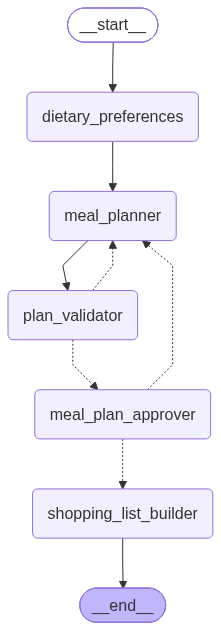

In [21]:
display(Image(data=recipe_graph.get_graph().draw_mermaid_png(), format="png"))

In [22]:
thread1_config = { "configurable": { "thread_id": "thread_11055" } }

In [23]:
def ask_human(payload: dict) -> dict:
  """Real interactive fallback when no simulator is supplied."""
  answer = input("Approve this meal plan? [Y/N] ").strip().lower()
  if answer in ("y", "yes"):
    return {"approved": True, "feedback": ""}
  return {"approved": False, "feedback": input("What should change? ").strip()}


In [24]:
def execute_workflow(user_request: str, user_id: str = "default_user", human_input=None, thread_id: str | None= None) -> dict:
  """Initialise the graph, run it, handle every interrupt, and return the final state."""

  thread_id = thread_id or f"{user_id}-{uuid.uuid4().hex[:8]}"
  config = {"configurable": {"thread_id": thread_id}}
  print(f"--- thread: {thread_id} ---")

  result = recipe_graph.invoke(
      {"user_request": user_request, "user_id": user_id},
      config=config
  )

  while result.get("__interrupt__"):
    print_interrupts(result["__interrupt__"])
    payload = result["__interrupt__"][0].value
    responder = human_input or ask_human
    result = recipe_graph.invoke(Command(resume=responder(payload)), config=config)

  print("\n===== CONVERSATION =====")
  print_conversation(result.get("messages", []))
  print("\n===== FINAL MEAL PLAN =====")
  print(pretty(result.get("meal_plan") or result.get("meal_plan_draft")))
  print("\n===== SHOPPING LIST =====")
  print(pretty(result.get("shopping_list")))
  print(f"\nEstimated total cost: {result.get('estimated_total_cost')}")
  print(f"Revisions requested: {result.get('revision_count', 0)}")
  return result

In [25]:
from langgraph.graph.state import CompiledStateGraph
from langchain_core.runnables import Runnable, RunnableConfig

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig):
    state_history = list(compiled_state_graph.get_state_history(config))

    for snapshot in reversed(state_history):
        print(f"Step: {snapshot.metadata['step']}")
        print("Current state:")
        print(snapshot.values)
        print(f"Next: {snapshot.next}")
        print()

# Test 1: Approve on the first try

In [26]:
t1 = execute_workflow(
    "Vegetarian meal plan for 2 people, budget $60 for the week.",
    user_id="alice",
    human_input=lambda p: {"approved": True, "feedback": ""},
)

--- thread: alice-b7ccd004 ---
[values] {'user_id': 'alice', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'messages': []}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='a6ce4812-b476-4aed-bca4-07e1dc2090d4')]}}
[values] {'user_id': 'alice', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Vegetarian m

[values] {'user_id': 'alice', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Caprese Salad', 'nutrition_info': 'Rich in protein and healthy fats from mozzarella, vitamins from tomatoes and basil', 'prep_time': '10 mins'}, 'lunch': {'recipe_name': 'Falafel', 'nutrition_info': 'High in protein and fiber from chickpeas, contains spices for antioxidants', 'prep_time': '30 mins (including soaking and frying)'}, 'dinner': {'recipe_name': 'Jollof Rice', 'nutrition_info': 'Carbohydrate-rich dish with vitamins from tomato and peppers, moderate fat from oil', 'prep_time': '40 mins'}}}, {'day': 2, 'meals': {'breakfast': {'recipe_name': 'Gazpacho Andaluz', 'nutrition_info': 'Low-calorie, hydr

# Test 2: One round of revision, then approval

In [27]:
_calls = {"n": 0}
def approve_after_one_revision(payload):
    _calls["n"] += 1
    if _calls["n"] == 1:
        return {"approved": False,
                "feedback": "Too much cheese. Swap at least three meals for legume-based dishes."}
    return {"approved": True, "feedback": ""}

t2 = execute_workflow(
    "Vegetarian meal plan for 2 people, budget $60 for the week.",
    user_id="bob",
    human_input=approve_after_one_revision,
)

--- thread: bob-ca07ea5a ---
[values] {'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'messages': []}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Vegetarian meal plan for 2 people, budget $60 for the week.', additional_kwargs={}, response_metadata={}, id='7f088de9-0800-42fd-866a-168b9cf63de2')]}}
[values] {'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Vegetarian meal pl

[values] {'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Cheese Arepas', 'key_nutrition_info': 'cornmeal-based, includes mozzarella cheese, moderate carbs and protein', 'prep_time': '15 minutes'}, 'lunch': {'recipe_name': 'Caprese Salad', 'key_nutrition_info': 'fresh vegetables and mozzarella, rich in calcium and vitamins, low calorie', 'prep_time': '10 minutes'}, 'dinner': {'recipe_name': 'Falafel', 'key_nutrition_info': 'high protein from chickpeas, fried preparation, rich in fiber', 'prep_time': '40 minutes (includes soaking time)'}}}, {'day': 2, 'meals': {'breakfast': {'recipe_name': 'Miso Soup', 'key_nutrition_info': 'low calorie, high in probiotics, contain

[values] {'user_id': 'bob', 'user_request': 'Vegetarian meal plan for 2 people, budget $60 for the week.', 'dietary_preferences': DietaryPreferences(diet_type='vegetarian', allergies=[], allergies_confirmed=False, dislikes=[], servings=2, days=7, calorie_target=None, budget=60.0, cuisine_preferences=[]), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Avocado Toast with Tomato and Basil', 'key_nutrition_info': 'healthy fats from avocado, vitamins from tomato and basil, moderate carbs', 'prep_time': '10 minutes'}, 'lunch': {'recipe_name': 'Falafel Wrap with Fresh Veggies', 'key_nutrition_info': 'protein from chickpeas, fiber and vitamins from vegetables and wrap, legume-based', 'prep_time': '20 minutes'}, 'dinner': {'recipe_name': "Vegetarian Shepherd's Pie", 'key_nutrition_info': 'vegetables and mashed potatoes, moderate protein, comforting carbs', 'prep_time': '45 minutes'}}}, {'day': 2, 'meals': {'breakfast': {'recipe_name': 'Oatmeal with Fresh Berries

# Test 3: Allergy as a hard safety constraint

In [28]:
t3 = execute_workflow(
    "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.",
    user_id="carol",
    human_input=lambda p: {"approved": True, "feedback": ""},
)

--- thread: carol-a58fb1d0 ---
[values] {'user_id': 'carol', 'user_request': "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", 'messages': []}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=3, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content="Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", additional_kwargs={}, response_metadata={}, id='9985cd2c-874e-44aa-9ff2-38ff8f5ed85a')]}}
[values] {'user_id': 'carol', 'user_request': "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=3, calorie_target=None, budget=None, cuisine_pref

[values] {'user_id': 'carol', 'user_request': "Vegan dinners only for 3 days, family of 4. I'm allergic to tree nuts and soy.", 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=3, calorie_target=None, budget=None, cuisine_preferences=[]), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'dinner': {'recipe_name': 'Falafel', 'key_nutrition_info': {'protein_source': 'chickpeas', 'diet': 'vegan', 'allergens': 'no tree nuts, no soy'}, 'prep_time_min': 30}}}, {'day': 2, 'meals': {'dinner': {'recipe_name': 'Jollof Rice', 'key_nutrition_info': {'protein_source': 'vegetables', 'diet': 'vegan', 'allergens': 'no tree nuts, no soy'}, 'prep_time_min': 45}}}, {'day': 3, 'meals': {'dinner': {'recipe_name': 'Nasi Goreng (modified without chicken and soy sauce)', 'key_nutrition_info': {'protein_source': 'vegetables or substitute legumes (user to adjust for soy allergy)', 'diet': 'vegan', 'allergens': 'n

# Test 4: Repeated rejection, hits the retry cap

In [29]:
t4 = execute_workflow(
    "Gluten-free plan for 5 days for one person, I love Mediterranean food.",
    user_id="dan",
    human_input=lambda p: {"approved": False, "feedback": "Still not varied enough."},
)

--- thread: dan-813385c7 ---
[values] {'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'messages': []}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'revision_count': 0, 'messages': [HumanMessage(content='Gluten-free plan for 5 days for one person, I love Mediterranean food.', additional_kwargs={}, response_metadata={}, id='969c3c98-8e60-47b0-9d92-d0b30c6b6387')]}}
[values] {'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'revision

[values] {'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Caprese Salad', 'key_nutrition': {'protein': 'moderate', 'fat': 'moderate', 'carbohydrates': 'low'}, 'prep_time': '10 minutes'}, 'lunch': {'recipe_name': 'Falafel', 'key_nutrition': {'protein': 'high (chickpeas)', 'fat': 'moderate (frying oil)', 'carbohydrates': 'moderate'}, 'prep_time': '30 minutes (excluding soak time)'}, 'dinner': {'recipe_name': 'Chicken Souvlaki', 'key_nutrition': {'protein': 'high (chicken)', 'fat': 'moderate (olive oil)', 'carbohydrates': 'low'}, 'prep_time': '30-40 minutes (including marination)'}}}, {'day': 2, 'meals': {'breakfast': {'recipe_name': 'Gazpa

[values] {'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Gazpacho Andaluz', 'key_nutrition': {'protein': 'low', 'fat': 'low', 'carbohydrates': 'low-moderate (vegetables)'}, 'prep_time': '10 minutes plus chilling time'}, 'lunch': {'recipe_name': 'Chicken Souvlaki', 'key_nutrition': {'protein': 'high (chicken)', 'fat': 'moderate (olive oil)', 'carbohydrates': 'low'}, 'prep_time': '30-40 minutes (including marination)'}, 'dinner': {'recipe_name': 'Paella Valenciana', 'key_nutrition': {'protein': 'moderate (chicken)', 'fat': 'low', 'carbohydrates': 'high (rice)'}, 'prep_time': '45 minutes'}}}, {'day': 2, 'meals': {'breakfast': {'recipe_name

[values] {'user_id': 'dan', 'user_request': 'Gluten-free plan for 5 days for one person, I love Mediterranean food.', 'dietary_preferences': DietaryPreferences(diet_type='gluten-free', allergies=[], allergies_confirmed=False, dislikes=[], servings=1, days=5, calorie_target=None, budget=None, cuisine_preferences=['Mediterranean']), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Caprese Salad', 'key_nutrition': {'protein': 'moderate (mozzarella)', 'fat': 'moderate (olive oil, cheese)', 'carbohydrates': 'low (vegetables)'}, 'prep_time': '10 minutes'}, 'lunch': {'recipe_name': 'Chicken Souvlaki', 'key_nutrition': {'protein': 'high (chicken)', 'fat': 'moderate (olive oil)', 'carbohydrates': 'low'}, 'prep_time': '30-40 minutes (including marination)'}, 'dinner': {'recipe_name': 'Paella Valenciana', 'key_nutrition': {'protein': 'moderate (chicken)', 'fat': 'low', 'carbohydrates': 'high (rice)'}, 'prep_time': '45 minutes'}}}, {'day': 2, 'meals': {'breakfast': {

# Test 5: Same user as Test 3 — exercises the store-backed memory

In [30]:
t5 = execute_workflow(
    "Same as before, but make it 7 days and add breakfasts.",
    user_id="carol",
    human_input=lambda p: {"approved": True, "feedback": ""},
)

--- thread: carol-6b1890d0 ---
[values] {'user_id': 'carol', 'user_request': 'Same as before, but make it 7 days and add breakfasts.', 'messages': []}
Parse dietary preferences
[updates] {'dietary_preferences': {'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=7, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Same as before, but make it 7 days and add breakfasts.', additional_kwargs={}, response_metadata={}, id='ae0495ba-ceb5-447f-825f-f8ccbc3f4616')]}}
[values] {'user_id': 'carol', 'user_request': 'Same as before, but make it 7 days and add breakfasts.', 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=7, calorie_target=None, budget=None, cuisine_preferences=[]), 'revision_count': 0, 'messages': [HumanMessage(content='Sam

[values] {'user_id': 'carol', 'user_request': 'Same as before, but make it 7 days and add breakfasts.', 'dietary_preferences': DietaryPreferences(diet_type='vegan', allergies=['tree nuts', 'soy'], allergies_confirmed=True, dislikes=[], servings=4, days=7, calorie_target=None, budget=None, cuisine_preferences=[]), 'meal_plan_draft': {'days': [{'day': 1, 'meals': {'breakfast': {'recipe_name': 'Falafel', 'key_nutrition_info': 'High in protein and fiber, vegan, nut-free, soy-free', 'prep_time_minutes': 40}, 'lunch': {'recipe_name': 'Hummus', 'key_nutrition_info': 'High in protein and healthy fats, vegan, nut-free, soy-free', 'prep_time_minutes': 10}, 'dinner': {'recipe_name': 'Jollof Rice', 'key_nutrition_info': 'Rich in carbohydrates and vitamins, vegan, nut-free, soy-free', 'prep_time_minutes': 50}}}, {'day': 2, 'meals': {'breakfast': {'recipe_name': 'Cheese Arepas (vegan alternative needed)', 'key_nutrition_info': 'High in carbs, moderate protein, nut-free, soy-free', 'prep_time_minutes

In [31]:
from langchain_core.messages import ToolMessage

def show_tool_usage(result: dict):
    calls = [(m.name, m.content[:120].replace("\n", " "))
             for m in result.get("messages", []) if isinstance(m, ToolMessage)]
    print(f"{len(calls)} tool invocations")
    for name, preview in calls:
        print(f"  - {name}: {preview}...")

show_tool_usage(t1)

10 tool invocations
  - recipes_knowledge_retriever: Bibimbap South Korea · Jeonju  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, b...
  - recipes_knowledge_retriever: Bibimbap South Korea · Jeonju  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, b...
  - recipes_knowledge_retriever: Chimichurri Steak Argentina · Pampas  Ingredients: - 1 lb flank or skirt steak - 1/2 cup fresh parsley, finely chopped -...
  - recipes_knowledge_retriever: Chimichurri Steak Argentina · Pampas  Ingredients: - 1 lb flank or skirt steak - 1/2 cup fresh parsley, finely chopped -...
  - recipes_knowledge_retriever: Chimichurri Steak Argentina · Pampas  Ingredients: - 1 lb flank or skirt steak - 1/2 cup fresh parsley, finely chopped -...
  - recipes_knowledge_retriever: Bibimbap South Korea · Jeonju  Ingredients: - 2 cups cooked white rice - 1 cup spinach, blanched - 1 cup bean sprouts, b...
  - get_recipe_ingredients: {"recipe":